In [1]:
import matplotlib.pyplot as plt
import numpy as np

In [2]:
def lineStartsWith(line, patterns):
    if isinstance(patterns, str):
        pattern = patterns
        lenPat = len(pattern)
        if len(line) < lenPat:
            return False
        if line[0:lenPat] == pattern:
            return True
        return False
    else:
        for pattern in patterns:
            lenPat = len(pattern)
            if len(line) < lenPat:
                continue
            if line[0:lenPat] == pattern:
                return True
        return False

In [3]:
def qFirstPerf(execution_time, m, n, k):
    # Taken from lawn 41
    # numOps = 4mnk - 2(m+n)k^2 + 4/3 k^3 + 3nk - mk - k^2 - 4/3k
    # When m\neq n=k, this simplifies to
    # numOps = 2mn^2 + 1/3 n^3 + n^2 - mn - 4/3 n
    # When m=n\neq k, this simplifies to
    # numOps = 4m^2k - 4mk^2 + 4/3 k^3 + 2mk - k^2 - 4/3 k
    numOps = 4*m*n*k - 2*(m+n)*k**2 + 4/3*k**3 + 3*n*k - m*k - k**2 - 4/3*k
    return numOps / (execution_time * 10**9)

def qSecondPerf(execution_time, m, n, k):
    #Taken from lawn 41
    #numOps = 4mnk - 2(m+n)k^2 + 4/3k^3 + 2mk - k^2 - 1/3k
    #When m\neq n=k, this simplifies to
    #numOps = 2nm^2 - 2/3m^3 + m^2 -1/3m
    #When m=n\neq k, this simplifies to
    #4m^2k - 4mk^2 + 4/3k^3 + 2mk - k^2 - 1/3k
    #double numOps = 4*m*n*k - 2*(m+n)*k*k + 4./3.*k*k*k + 2*m*k - k*k - 1./3.*k;
    numOps = 4*m*n*k - 2*(m+n)*k**2 + 4/3*k**3 + 2*m*k - k**2 - 1/3*k
    return numOps / (execution_time * 10**9)

In [4]:
def createFigure(xVec, yVecs, labelVec, title, xLabel, yLabel, filename=None, xTicks=None, yTicks=None, yScale=None, nDash=0):
    fig,ax = plt.subplots()
    ax.set_title(title)
    ax.set_xlabel(xLabel)
    ax.set_ylabel(yLabel)

    numY = yVecs.shape[0]
    numL = labelVec.shape[0]

    if numY != numL:
        return

    if xTicks != None:
        ax.set_xticks(xTicks)

    if yTicks != None:
        ax.set_yticks(yTicks)

    if yScale != None:
        ax.set_yscale(yScale)

    # Plot the first nDash elements as dashed lines
    for i in range(nDash):
        ax.plot(xVec, yVecs[i], '--', label=labelVec[i])
    # Plot the rest normally
    for i in range(nDash, numY):
        ax.plot(xVec, yVecs[i], label=labelVec[i])

    ax.legend()
    if filename != None:
        fig.savefig(filename)

In [5]:
def parseFile(filename, perf=False):
    # Row 1 is for single
    # Row 2 is for double
    # Row 3 is for single complex
    # Row 4 is for double complex
    # Col 1 is for opt (AOCL)
    # Col 2 is for ref (existing version without my changes)
    # Col 3 is for new (new version with my proposed changes)
    qrTimes = np.zeros((4,3))
    qlTimes = np.zeros((4,3))
    rqTimes = np.zeros((4,3))
    lqTimes = np.zeros((4,3))

    mVec = np.zeros(0).astype('int')
    nVec = np.zeros(0).astype('int')
    kVec = np.zeros(0).astype('int')

    single_real_qrOpt = np.zeros(0)
    single_real_qrRef = np.zeros(0)
    single_real_qrNew = np.zeros(0)
    single_real_qlOpt = np.zeros(0)
    single_real_qlRef = np.zeros(0)
    single_real_qlNew = np.zeros(0)
    single_real_rqOpt = np.zeros(0)
    single_real_rqRef = np.zeros(0)
    single_real_rqNew = np.zeros(0)
    single_real_lqOpt = np.zeros(0)
    single_real_lqRef = np.zeros(0)
    single_real_lqNew = np.zeros(0)
    double_real_qrOpt = np.zeros(0)
    double_real_qrRef = np.zeros(0)
    double_real_qrNew = np.zeros(0)
    double_real_qlOpt = np.zeros(0)
    double_real_qlRef = np.zeros(0)
    double_real_qlNew = np.zeros(0)
    double_real_rqOpt = np.zeros(0)
    double_real_rqRef = np.zeros(0)
    double_real_rqNew = np.zeros(0)
    double_real_lqOpt = np.zeros(0)
    double_real_lqRef = np.zeros(0)
    double_real_lqNew = np.zeros(0)
    single_complex_qrOpt = np.zeros(0)
    single_complex_qrRef = np.zeros(0)
    single_complex_qrNew = np.zeros(0)
    single_complex_qlOpt = np.zeros(0)
    single_complex_qlRef = np.zeros(0)
    single_complex_qlNew = np.zeros(0)
    single_complex_rqOpt = np.zeros(0)
    single_complex_rqRef = np.zeros(0)
    single_complex_rqNew = np.zeros(0)
    single_complex_lqOpt = np.zeros(0)
    single_complex_lqRef = np.zeros(0)
    single_complex_lqNew = np.zeros(0)
    double_complex_qrOpt = np.zeros(0)
    double_complex_qrRef = np.zeros(0)
    double_complex_qrNew = np.zeros(0)
    double_complex_qlOpt = np.zeros(0)
    double_complex_qlRef = np.zeros(0)
    double_complex_qlNew = np.zeros(0)
    double_complex_rqOpt = np.zeros(0)
    double_complex_rqRef = np.zeros(0)
    double_complex_rqNew = np.zeros(0)
    double_complex_lqOpt = np.zeros(0)
    double_complex_lqRef = np.zeros(0)
    double_complex_lqNew = np.zeros(0)
    
    firstRun = True
    rowIndex = -1
    colIndex = -1
    numRepeat = 1
    with open(filename,'r') as file:
        lines = file.readlines()
        for line in lines:
            if lineStartsWith(line, "m="):
                line2 = line.split(" ")
                mVec = np.append(mVec, int(line2[0][2:]))
                nVec = np.append(nVec, int(line2[1][2:]))
                kVec = np.append(kVec, int(line2[2][2:]))
                if firstRun:
                    firstRun = False
                else:
                    # Now, we average the values currently in xTimes (if needed)
                    qrTimes = qrTimes / numRepeat
                    qlTimes = qlTimes / numRepeat
                    rqTimes = rqTimes / numRepeat
                    lqTimes = lqTimes / numRepeat
                    # Now, we must append each column to the correct return vector
                    single_real_qrOpt = np.append(single_real_qrOpt, qrTimes[0,0])
                    single_real_qrRef = np.append(single_real_qrRef, qrTimes[0,1])
                    single_real_qrNew = np.append(single_real_qrNew, qrTimes[0,2])
                    double_real_qrOpt = np.append(double_real_qrOpt, qrTimes[1,0])
                    double_real_qrRef = np.append(double_real_qrRef, qrTimes[1,1])
                    double_real_qrNew = np.append(double_real_qrNew, qrTimes[1,2])
                    single_complex_qrOpt = np.append(single_complex_qrOpt, qrTimes[2,0])
                    single_complex_qrRef = np.append(single_complex_qrRef, qrTimes[2,1])
                    single_complex_qrNew = np.append(single_complex_qrNew, qrTimes[2,2])
                    double_complex_qrOpt = np.append(double_complex_qrOpt, qrTimes[3,0])
                    double_complex_qrRef = np.append(double_complex_qrRef, qrTimes[3,1])
                    double_complex_qrNew = np.append(double_complex_qrNew, qrTimes[3,2])
                    single_real_qlOpt = np.append(single_real_qlOpt, qlTimes[0,0])
                    single_real_qlRef = np.append(single_real_qlRef, qlTimes[0,1])
                    single_real_qlNew = np.append(single_real_qlNew, qlTimes[0,2])
                    double_real_qlOpt = np.append(double_real_qlOpt, qlTimes[1,0])
                    double_real_qlRef = np.append(double_real_qlRef, qlTimes[1,1])
                    double_real_qlNew = np.append(double_real_qlNew, qlTimes[1,2])
                    single_complex_qlOpt = np.append(single_complex_qlOpt, qlTimes[2,0])
                    single_complex_qlRef = np.append(single_complex_qlRef, qlTimes[2,1])
                    single_complex_qlNew = np.append(single_complex_qlNew, qlTimes[2,2])
                    double_complex_qlOpt = np.append(double_complex_qlOpt, qlTimes[3,0])
                    double_complex_qlRef = np.append(double_complex_qlRef, qlTimes[3,1])
                    double_complex_qlNew = np.append(double_complex_qlNew, qlTimes[3,2])
                    single_real_rqOpt = np.append(single_real_rqOpt, rqTimes[0,0])
                    single_real_rqRef = np.append(single_real_rqRef, rqTimes[0,1])
                    single_real_rqNew = np.append(single_real_rqNew, rqTimes[0,2])
                    double_real_rqOpt = np.append(double_real_rqOpt, rqTimes[1,0])
                    double_real_rqRef = np.append(double_real_rqRef, rqTimes[1,1])
                    double_real_rqNew = np.append(double_real_rqNew, rqTimes[1,2])
                    single_complex_rqOpt = np.append(single_complex_rqOpt, rqTimes[2,0])
                    single_complex_rqRef = np.append(single_complex_rqRef, rqTimes[2,1])
                    single_complex_rqNew = np.append(single_complex_rqNew, rqTimes[2,2])
                    double_complex_rqOpt = np.append(double_complex_rqOpt, rqTimes[3,0])
                    double_complex_rqRef = np.append(double_complex_rqRef, rqTimes[3,1])
                    double_complex_rqNew = np.append(double_complex_rqNew, rqTimes[3,2])
                    single_real_lqOpt = np.append(single_real_lqOpt, lqTimes[0,0])
                    single_real_lqRef = np.append(single_real_lqRef, lqTimes[0,1])
                    single_real_lqNew = np.append(single_real_lqNew, lqTimes[0,2])
                    double_real_lqOpt = np.append(double_real_lqOpt, lqTimes[1,0])
                    double_real_lqRef = np.append(double_real_lqRef, lqTimes[1,1])
                    double_real_lqNew = np.append(double_real_lqNew, lqTimes[1,2])
                    single_complex_lqOpt = np.append(single_complex_lqOpt, lqTimes[2,0])
                    single_complex_lqRef = np.append(single_complex_lqRef, lqTimes[2,1])
                    single_complex_lqNew = np.append(single_complex_lqNew, lqTimes[2,2])
                    double_complex_lqOpt = np.append(double_complex_lqOpt, lqTimes[3,0])
                    double_complex_lqRef = np.append(double_complex_lqRef, lqTimes[3,1])
                    double_complex_lqNew = np.append(double_complex_lqNew, lqTimes[3,2])
                    # Reset the time value arrays
                    qrTimes = np.zeros((4,3))
                    qlTimes = np.zeros((4,3))
                    rqTimes = np.zeros((4,3))
                    lqTimes = np.zeros((4,3))
            elif lineStartsWith(line, "Testing file"):
                line2 = line.split(' ')
                numRepeat = int(line2[3]) # This is brittle. TODO: Consider a more sane check, but not high priority
            elif lineStartsWith(line, "Single Comp"):
                rowIndex = 2
            elif lineStartsWith(line, "Double Comp"):
                rowIndex = 3
            elif lineStartsWith(line, "Single"):
                rowIndex = 0
            elif lineStartsWith(line, "Double"):
                rowIndex = 1
            elif lineStartsWith(line, ["QR","QL","RQ","LQ"]):
                line2 = line.split(' ')
                if lineStartsWith(line2[1],"AOCL"):
                    colIndex = 0
                elif lineStartsWith(line2[1],"Ref"):
                    colIndex = 1
                elif lineStartsWith(line2[1],"New"):
                    colIndex = 2
                else:
                    raise Exception(f'Invalid input file: No label for which algorithm is used.\nInvalid line: {line}')
                values = line2[2].split(":")
                if perf:
                    value = float(values[1])
                else:
                    value = float(values[0])
                if line2[0] == "QR":
                    qrTimes[rowIndex,colIndex] += value
                elif line2[0] == "QL":
                    qlTimes[rowIndex,colIndex] += value
                elif line2[0] == "RQ":
                    rqTimes[rowIndex,colIndex] += value
                else: # elif line2[0] == "LQ":
                    lqTimes[rowIndex,colIndex] += value
            else:
                raise Exception(f'Invalid input file.\n Unexpected line: {line}')
    # Now, we average the values currently in xTimes (if needed)
    qrTimes = qrTimes / numRepeat
    qlTimes = qlTimes / numRepeat
    rqTimes = rqTimes / numRepeat
    lqTimes = lqTimes / numRepeat
    # Now, we must append each column to the correct return vector
    single_real_qrOpt = np.append(single_real_qrOpt, qrTimes[0,0])
    single_real_qrRef = np.append(single_real_qrRef, qrTimes[0,1])
    single_real_qrNew = np.append(single_real_qrNew, qrTimes[0,2])
    double_real_qrOpt = np.append(double_real_qrOpt, qrTimes[1,0])
    double_real_qrRef = np.append(double_real_qrRef, qrTimes[1,1])
    double_real_qrNew = np.append(double_real_qrNew, qrTimes[1,2])
    single_complex_qrOpt = np.append(single_complex_qrOpt, qrTimes[2,0])
    single_complex_qrRef = np.append(single_complex_qrRef, qrTimes[2,1])
    single_complex_qrNew = np.append(single_complex_qrNew, qrTimes[2,2])
    double_complex_qrOpt = np.append(double_complex_qrOpt, qrTimes[3,0])
    double_complex_qrRef = np.append(double_complex_qrRef, qrTimes[3,1])
    double_complex_qrNew = np.append(double_complex_qrNew, qrTimes[3,2])
    single_real_qlOpt = np.append(single_real_qlOpt, qlTimes[0,0])
    single_real_qlRef = np.append(single_real_qlRef, qlTimes[0,1])
    single_real_qlNew = np.append(single_real_qlNew, qlTimes[0,2])
    double_real_qlOpt = np.append(double_real_qlOpt, qlTimes[1,0])
    double_real_qlRef = np.append(double_real_qlRef, qlTimes[1,1])
    double_real_qlNew = np.append(double_real_qlNew, qlTimes[1,2])
    single_complex_qlOpt = np.append(single_complex_qlOpt, qlTimes[2,0])
    single_complex_qlRef = np.append(single_complex_qlRef, qlTimes[2,1])
    single_complex_qlNew = np.append(single_complex_qlNew, qlTimes[2,2])
    double_complex_qlOpt = np.append(double_complex_qlOpt, qlTimes[3,0])
    double_complex_qlRef = np.append(double_complex_qlRef, qlTimes[3,1])
    double_complex_qlNew = np.append(double_complex_qlNew, qlTimes[3,2])
    single_real_rqOpt = np.append(single_real_rqOpt, rqTimes[0,0])
    single_real_rqRef = np.append(single_real_rqRef, rqTimes[0,1])
    single_real_rqNew = np.append(single_real_rqNew, rqTimes[0,2])
    double_real_rqOpt = np.append(double_real_rqOpt, rqTimes[1,0])
    double_real_rqRef = np.append(double_real_rqRef, rqTimes[1,1])
    double_real_rqNew = np.append(double_real_rqNew, rqTimes[1,2])
    single_complex_rqOpt = np.append(single_complex_rqOpt, rqTimes[2,0])
    single_complex_rqRef = np.append(single_complex_rqRef, rqTimes[2,1])
    single_complex_rqNew = np.append(single_complex_rqNew, rqTimes[2,2])
    double_complex_rqOpt = np.append(double_complex_rqOpt, rqTimes[3,0])
    double_complex_rqRef = np.append(double_complex_rqRef, rqTimes[3,1])
    double_complex_rqNew = np.append(double_complex_rqNew, rqTimes[3,2])
    single_real_lqOpt = np.append(single_real_lqOpt, lqTimes[0,0])
    single_real_lqRef = np.append(single_real_lqRef, lqTimes[0,1])
    single_real_lqNew = np.append(single_real_lqNew, lqTimes[0,2])
    double_real_lqOpt = np.append(double_real_lqOpt, lqTimes[1,0])
    double_real_lqRef = np.append(double_real_lqRef, lqTimes[1,1])
    double_real_lqNew = np.append(double_real_lqNew, lqTimes[1,2])
    single_complex_lqOpt = np.append(single_complex_lqOpt, lqTimes[2,0])
    single_complex_lqRef = np.append(single_complex_lqRef, lqTimes[2,1])
    single_complex_lqNew = np.append(single_complex_lqNew, lqTimes[2,2])
    double_complex_lqOpt = np.append(double_complex_lqOpt, lqTimes[3,0])
    double_complex_lqRef = np.append(double_complex_lqRef, lqTimes[3,1])
    double_complex_lqNew = np.append(double_complex_lqNew, lqTimes[3,2])

    return (mVec, nVec, kVec, single_real_qrOpt, single_real_qrRef, single_real_qrNew, single_real_qlOpt, single_real_qlRef, single_real_qlNew, \
           single_real_rqOpt, single_real_rqRef, single_real_rqNew, single_real_lqOpt, single_real_lqRef, single_real_lqNew, \
           double_real_qrOpt, double_real_qrRef, double_real_qrNew, double_real_qlOpt, double_real_qlRef, double_real_qlNew, \
           double_real_rqOpt, double_real_rqRef, double_real_rqNew, double_real_lqOpt, double_real_lqRef, double_real_lqNew, \
           single_complex_qrOpt, single_complex_qrRef, single_complex_qrNew, single_complex_qlOpt, single_complex_qlRef, single_complex_qlNew, \
           single_complex_rqOpt, single_complex_rqRef, single_complex_rqNew, single_complex_lqOpt, single_complex_lqRef, single_complex_lqNew, \
           double_complex_qrOpt, double_complex_qrRef, double_complex_qrNew, double_complex_qlOpt, double_complex_qlRef, double_complex_qlNew, \
           double_complex_rqOpt, double_complex_rqRef, double_complex_rqNew, double_complex_lqOpt, double_complex_lqRef, double_complex_lqNew)

In [6]:
(mVec, nVec, kVec, single_real_qrOpt, single_real_qrRef, single_real_qrNew, single_real_qlOpt, single_real_qlRef, single_real_qlNew, \
single_real_rqOpt, single_real_rqRef, single_real_rqNew, single_real_lqOpt, single_real_lqRef, single_real_lqNew, \
double_real_qrOpt, double_real_qrRef, double_real_qrNew, double_real_qlOpt, double_real_qlRef, double_real_qlNew, \
double_real_rqOpt, double_real_rqRef, double_real_rqNew, double_real_lqOpt, double_real_lqRef, double_real_lqNew, \
single_complex_qrOpt, single_complex_qrRef, single_complex_qrNew, single_complex_qlOpt, single_complex_qlRef, single_complex_qlNew, \
single_complex_rqOpt, single_complex_rqRef, single_complex_rqNew, single_complex_lqOpt, single_complex_lqRef, single_complex_lqNew, \
double_complex_qrOpt, double_complex_qrRef, double_complex_qrNew, double_complex_qlOpt, double_complex_qlRef, double_complex_qlNew, \
double_complex_rqOpt, double_complex_rqRef, double_complex_rqNew, double_complex_lqOpt, double_complex_lqRef, double_complex_lqNew) = parseFile("squareTiming.05.September.2025.txt")

In [7]:
x_title = "Number of reflectors (k)"
y_title = "Execution time (seconds)"

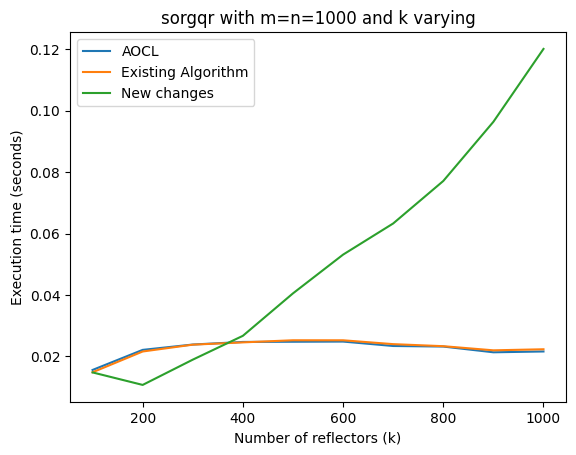

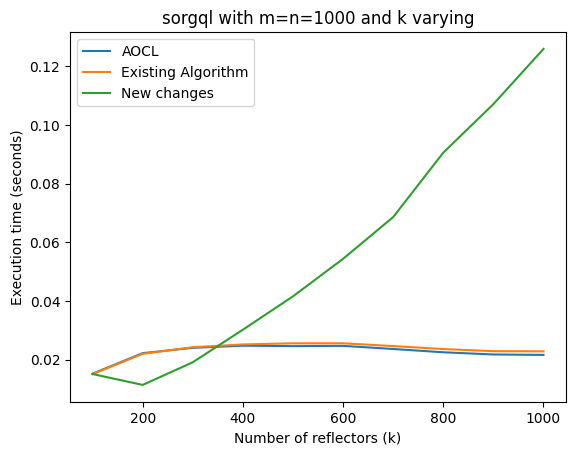

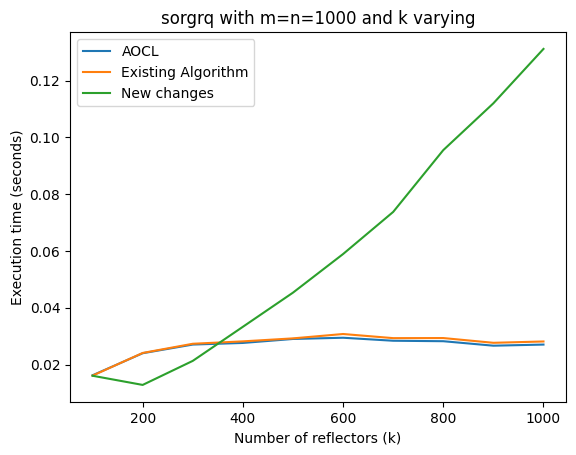

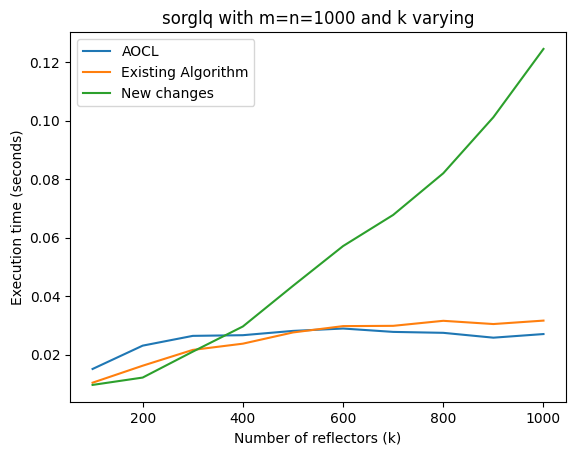

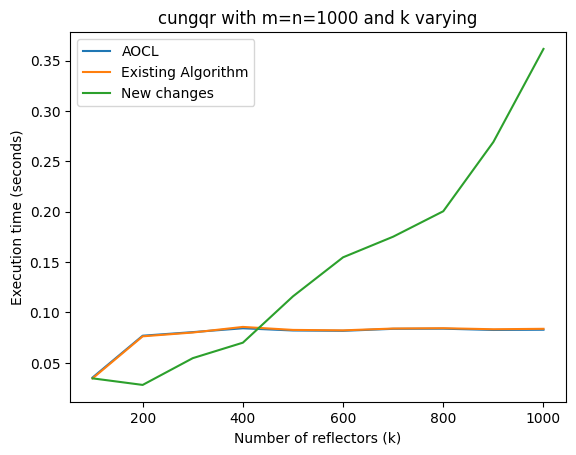

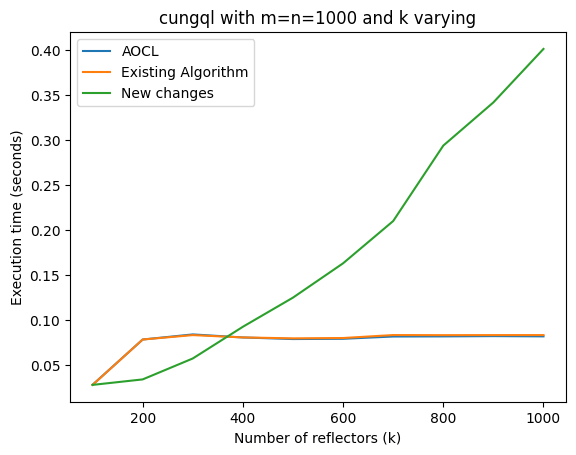

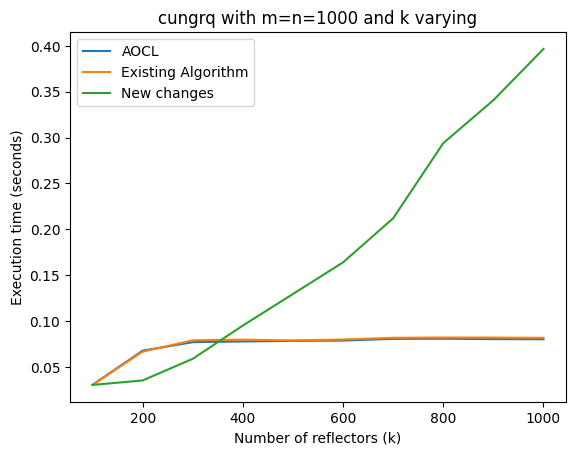

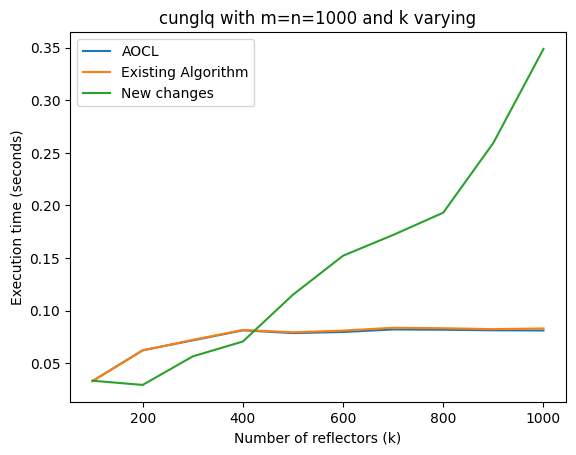

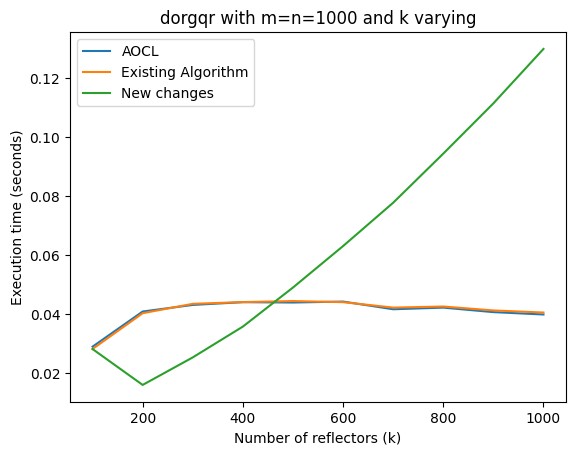

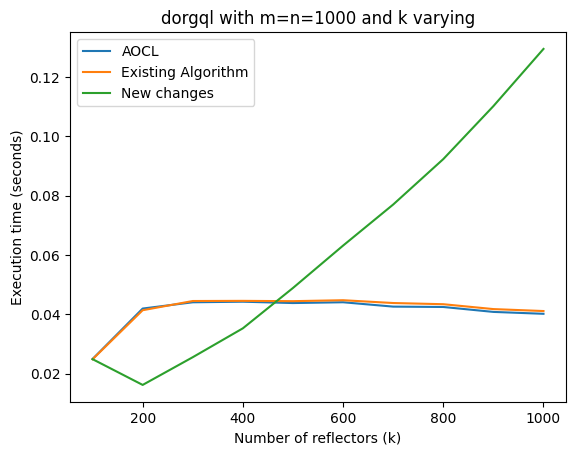

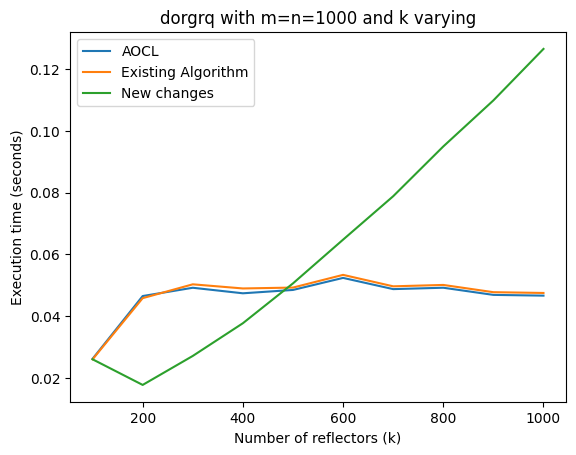

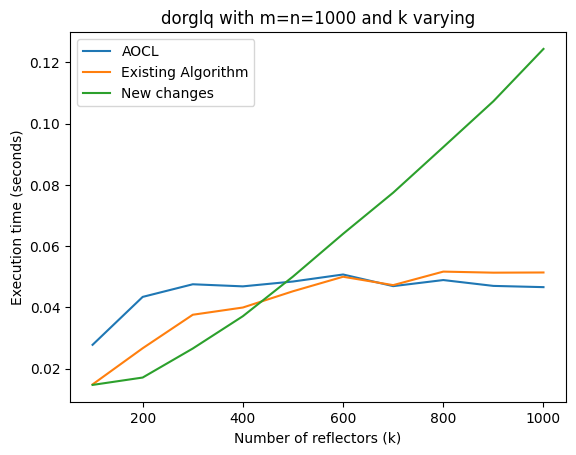

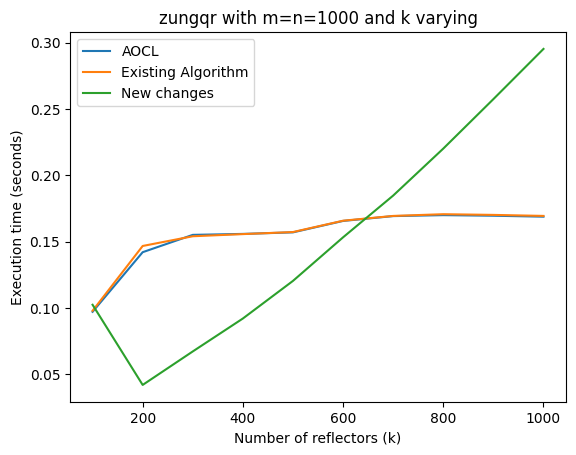

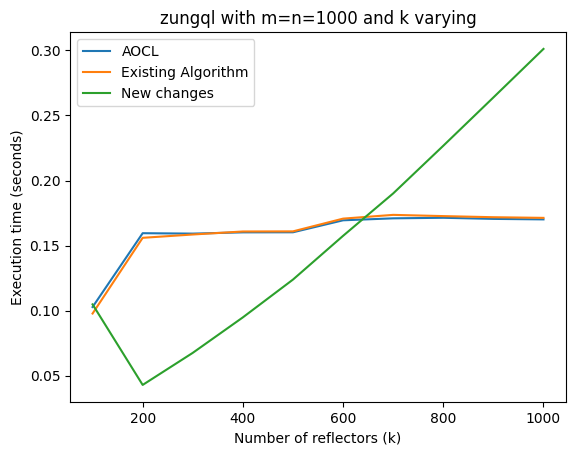

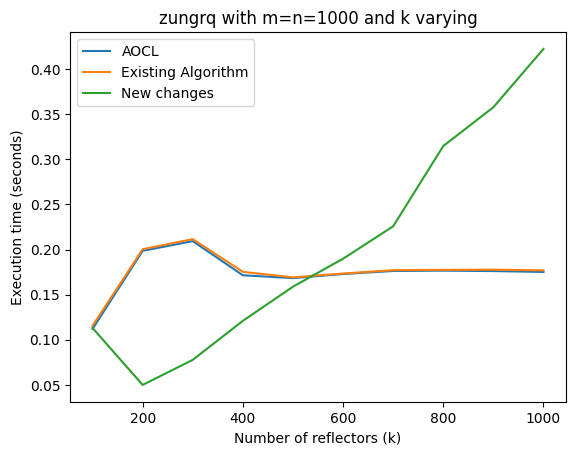

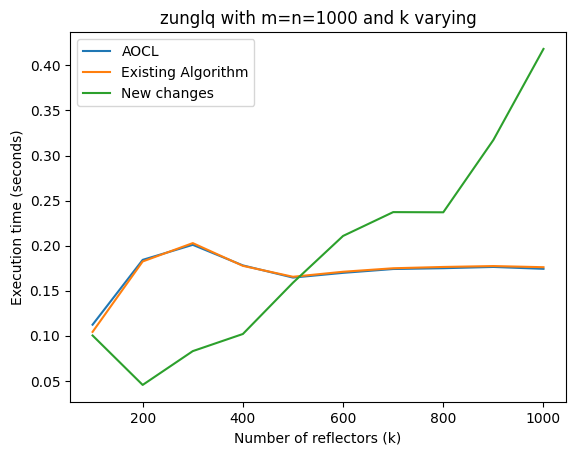

In [8]:
createFigure(kVec, np.array([single_real_qrOpt, single_real_qrRef, single_real_qrNew]), np.array(["AOCL", "Existing Algorithm", "New changes"]),
             "sorgqr with m=n=1000 and k varying", x_title, y_title)
createFigure(kVec, np.array([single_real_qlOpt, single_real_qlRef, single_real_qlNew]), np.array(["AOCL", "Existing Algorithm", "New changes"]),
             "sorgql with m=n=1000 and k varying", x_title, y_title)
createFigure(kVec, np.array([single_real_rqOpt, single_real_rqRef, single_real_rqNew]), np.array(["AOCL", "Existing Algorithm", "New changes"]),
             "sorgrq with m=n=1000 and k varying", x_title, y_title)
createFigure(kVec, np.array([single_real_lqOpt, single_real_lqRef, single_real_lqNew]), np.array(["AOCL", "Existing Algorithm", "New changes"]),
             "sorglq with m=n=1000 and k varying", x_title, y_title)
#########################################################################################################################################################
createFigure(kVec, np.array([single_complex_qrOpt, single_complex_qrRef, single_complex_qrNew]), np.array(["AOCL", "Existing Algorithm", "New changes"]),
             "cungqr with m=n=1000 and k varying", x_title, y_title)
createFigure(kVec, np.array([single_complex_qlOpt, single_complex_qlRef, single_complex_qlNew]), np.array(["AOCL", "Existing Algorithm", "New changes"]),
             "cungql with m=n=1000 and k varying", x_title, y_title)
createFigure(kVec, np.array([single_complex_rqOpt, single_complex_rqRef, single_complex_rqNew]), np.array(["AOCL", "Existing Algorithm", "New changes"]),
             "cungrq with m=n=1000 and k varying", x_title, y_title)
createFigure(kVec, np.array([single_complex_lqOpt, single_complex_lqRef, single_complex_lqNew]), np.array(["AOCL", "Existing Algorithm", "New changes"]),
             "cunglq with m=n=1000 and k varying", x_title, y_title)
#########################################################################################################################################################
createFigure(kVec, np.array([double_real_qrOpt, double_real_qrRef, double_real_qrNew]), np.array(["AOCL", "Existing Algorithm", "New changes"]),
             "dorgqr with m=n=1000 and k varying", x_title, y_title)
createFigure(kVec, np.array([double_real_qlOpt, double_real_qlRef, double_real_qlNew]), np.array(["AOCL", "Existing Algorithm", "New changes"]),
             "dorgql with m=n=1000 and k varying", x_title, y_title)
createFigure(kVec, np.array([double_real_rqOpt, double_real_rqRef, double_real_rqNew]), np.array(["AOCL", "Existing Algorithm", "New changes"]),
             "dorgrq with m=n=1000 and k varying", x_title, y_title)
createFigure(kVec, np.array([double_real_lqOpt, double_real_lqRef, double_real_lqNew]), np.array(["AOCL", "Existing Algorithm", "New changes"]),
             "dorglq with m=n=1000 and k varying", x_title, y_title)
#########################################################################################################################################################
createFigure(kVec, np.array([double_complex_qrOpt, double_complex_qrRef, double_complex_qrNew]), np.array(["AOCL", "Existing Algorithm", "New changes"]),
             "zungqr with m=n=1000 and k varying", x_title, y_title)
createFigure(kVec, np.array([double_complex_qlOpt, double_complex_qlRef, double_complex_qlNew]), np.array(["AOCL", "Existing Algorithm", "New changes"]),
             "zungql with m=n=1000 and k varying", x_title, y_title)
createFigure(kVec, np.array([double_complex_rqOpt, double_complex_rqRef, double_complex_rqNew]), np.array(["AOCL", "Existing Algorithm", "New changes"]),
             "zungrq with m=n=1000 and k varying", x_title, y_title)
createFigure(kVec, np.array([double_complex_lqOpt, double_complex_lqRef, double_complex_lqNew]), np.array(["AOCL", "Existing Algorithm", "New changes"]),
             "zunglq with m=n=1000 and k varying", x_title, y_title)

In [9]:
(mVec, nVec, kVec, single_real_qrOpt, single_real_qrRef, single_real_qrNew, single_real_qlOpt, single_real_qlRef, single_real_qlNew, \
single_real_rqOpt, single_real_rqRef, single_real_rqNew, single_real_lqOpt, single_real_lqRef, single_real_lqNew, \
double_real_qrOpt, double_real_qrRef, double_real_qrNew, double_real_qlOpt, double_real_qlRef, double_real_qlNew, \
double_real_rqOpt, double_real_rqRef, double_real_rqNew, double_real_lqOpt, double_real_lqRef, double_real_lqNew, \
single_complex_qrOpt, single_complex_qrRef, single_complex_qrNew, single_complex_qlOpt, single_complex_qlRef, single_complex_qlNew, \
single_complex_rqOpt, single_complex_rqRef, single_complex_rqNew, single_complex_lqOpt, single_complex_lqRef, single_complex_lqNew, \
double_complex_qrOpt, double_complex_qrRef, double_complex_qrNew, double_complex_qlOpt, double_complex_qlRef, double_complex_qlNew, \
double_complex_rqOpt, double_complex_rqRef, double_complex_rqNew, double_complex_lqOpt, double_complex_lqRef, double_complex_lqNew) = parseFile("squareTiming.05.September.2025.txt", perf=True)

In [10]:
x_title = "Number of reflectors (k)"
y_title = "Operations per Second (GFlop/s)"

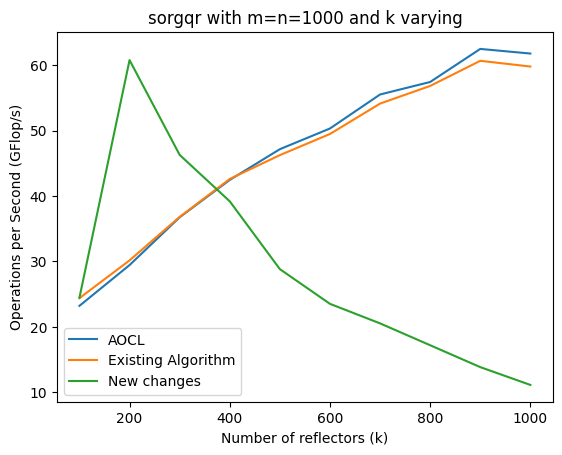

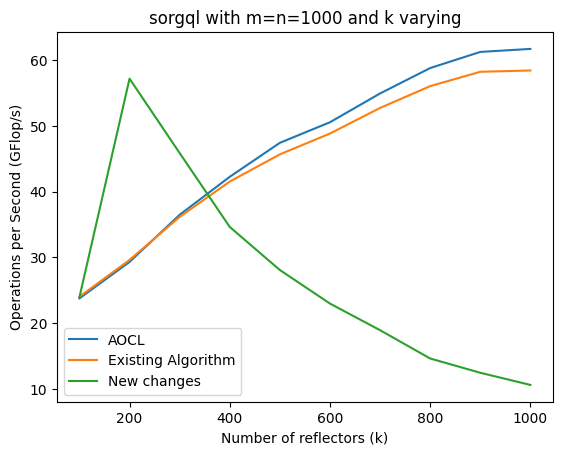

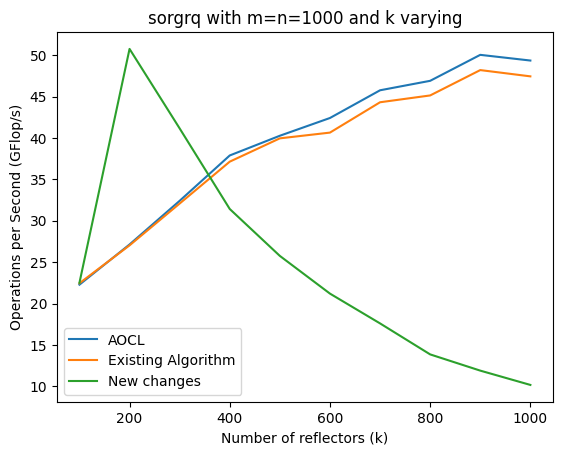

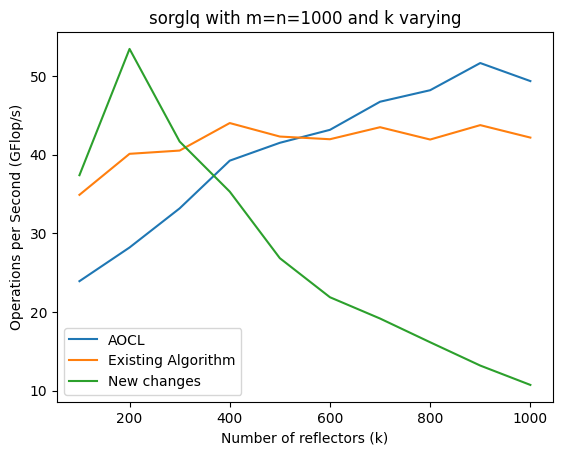

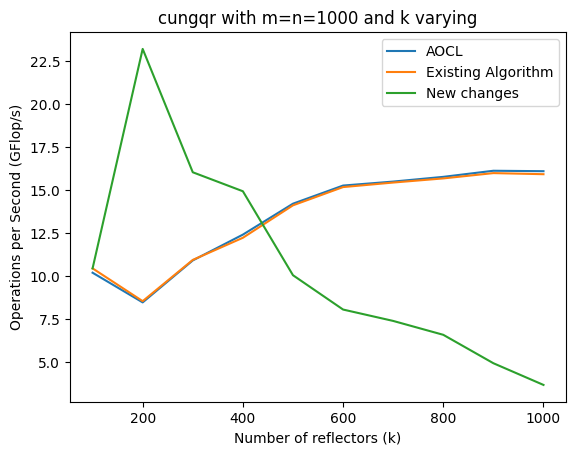

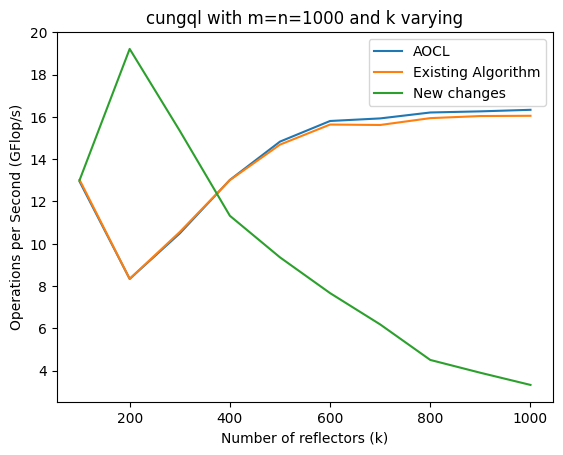

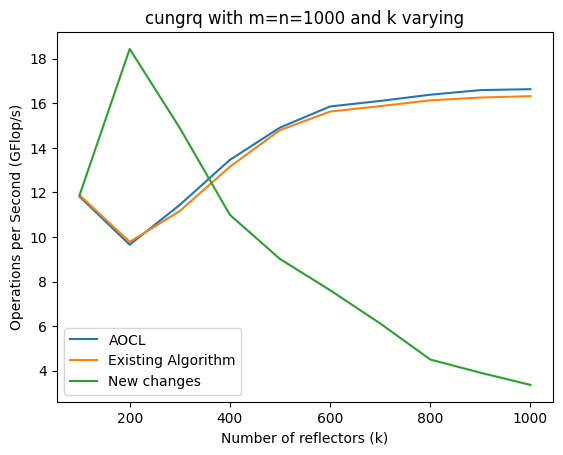

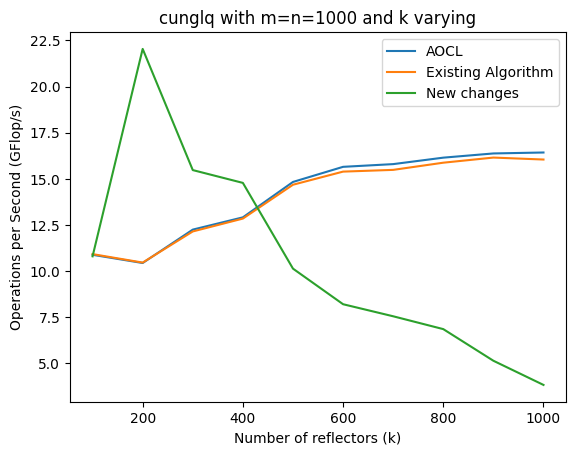

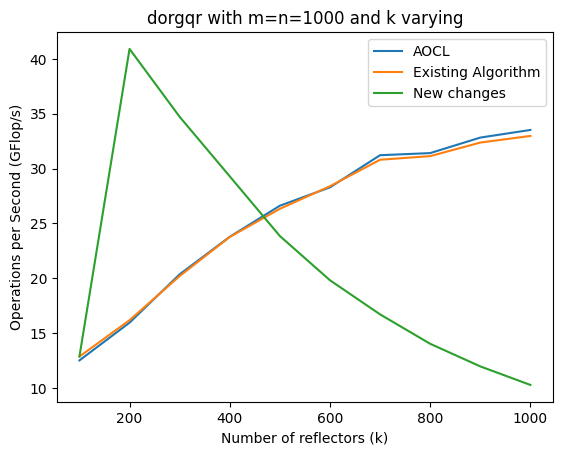

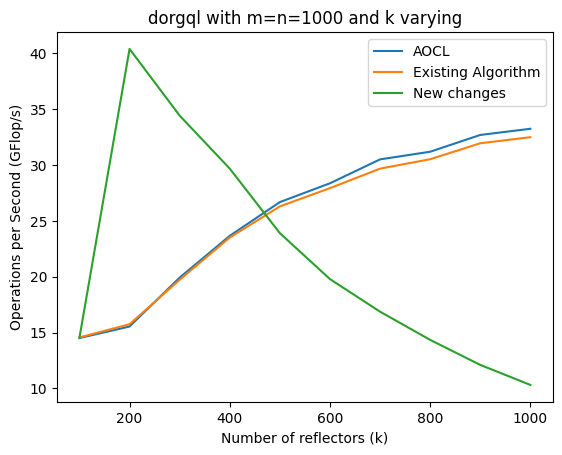

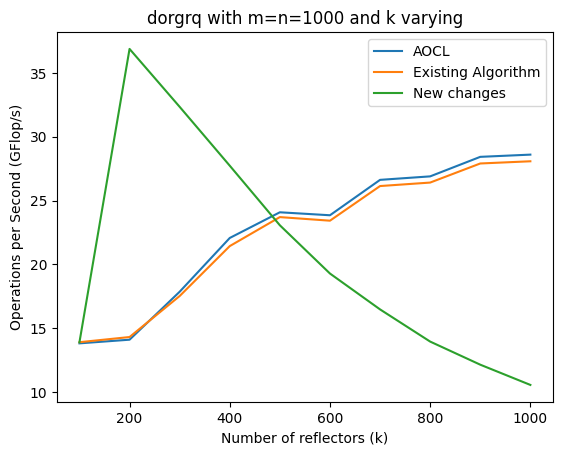

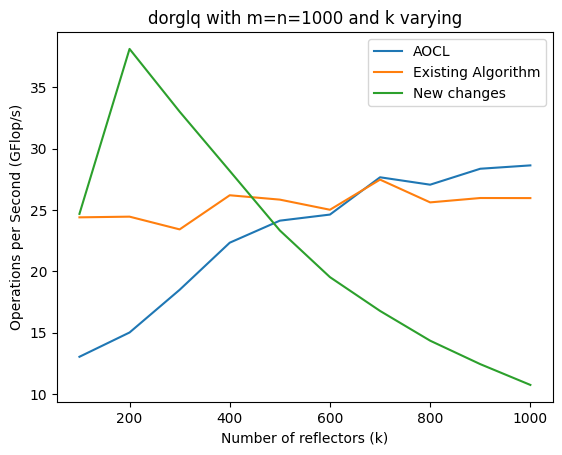

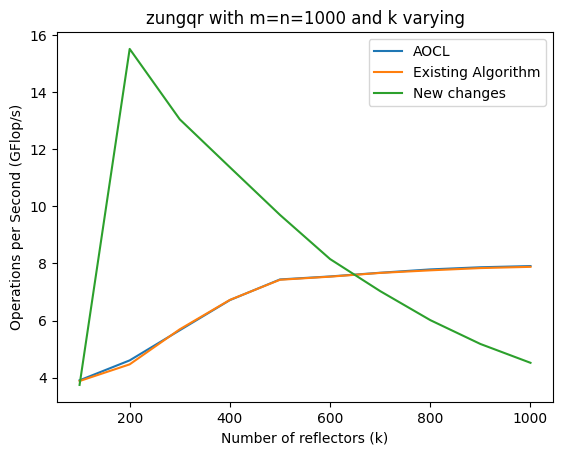

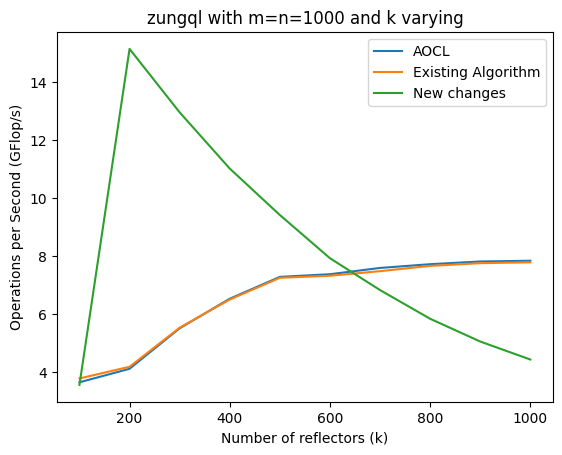

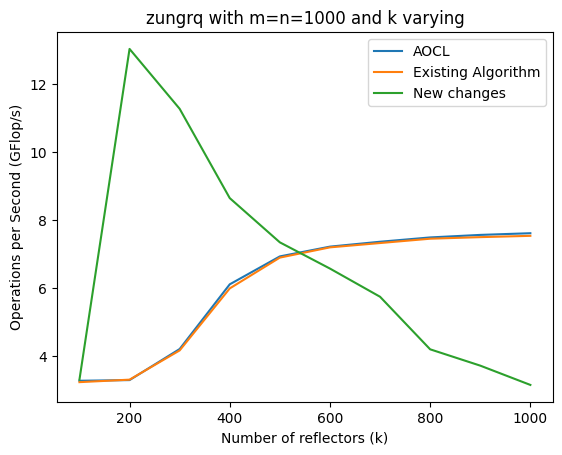

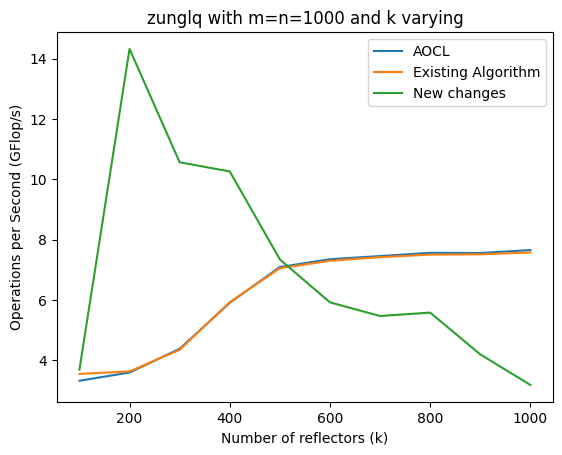

In [11]:
createFigure(kVec, np.array([single_real_qrOpt, single_real_qrRef, single_real_qrNew]), np.array(["AOCL", "Existing Algorithm", "New changes"]),
             "sorgqr with m=n=1000 and k varying", x_title, y_title)
createFigure(kVec, np.array([single_real_qlOpt, single_real_qlRef, single_real_qlNew]), np.array(["AOCL", "Existing Algorithm", "New changes"]),
             "sorgql with m=n=1000 and k varying", x_title, y_title)
createFigure(kVec, np.array([single_real_rqOpt, single_real_rqRef, single_real_rqNew]), np.array(["AOCL", "Existing Algorithm", "New changes"]),
             "sorgrq with m=n=1000 and k varying", x_title, y_title)
createFigure(kVec, np.array([single_real_lqOpt, single_real_lqRef, single_real_lqNew]), np.array(["AOCL", "Existing Algorithm", "New changes"]),
             "sorglq with m=n=1000 and k varying", x_title, y_title)
#########################################################################################################################################################
createFigure(kVec, np.array([single_complex_qrOpt, single_complex_qrRef, single_complex_qrNew]), np.array(["AOCL", "Existing Algorithm", "New changes"]),
             "cungqr with m=n=1000 and k varying", x_title, y_title)
createFigure(kVec, np.array([single_complex_qlOpt, single_complex_qlRef, single_complex_qlNew]), np.array(["AOCL", "Existing Algorithm", "New changes"]),
             "cungql with m=n=1000 and k varying", x_title, y_title)
createFigure(kVec, np.array([single_complex_rqOpt, single_complex_rqRef, single_complex_rqNew]), np.array(["AOCL", "Existing Algorithm", "New changes"]),
             "cungrq with m=n=1000 and k varying", x_title, y_title)
createFigure(kVec, np.array([single_complex_lqOpt, single_complex_lqRef, single_complex_lqNew]), np.array(["AOCL", "Existing Algorithm", "New changes"]),
             "cunglq with m=n=1000 and k varying", x_title, y_title)
#########################################################################################################################################################
createFigure(kVec, np.array([double_real_qrOpt, double_real_qrRef, double_real_qrNew]), np.array(["AOCL", "Existing Algorithm", "New changes"]),
             "dorgqr with m=n=1000 and k varying", x_title, y_title)
createFigure(kVec, np.array([double_real_qlOpt, double_real_qlRef, double_real_qlNew]), np.array(["AOCL", "Existing Algorithm", "New changes"]),
             "dorgql with m=n=1000 and k varying", x_title, y_title)
createFigure(kVec, np.array([double_real_rqOpt, double_real_rqRef, double_real_rqNew]), np.array(["AOCL", "Existing Algorithm", "New changes"]),
             "dorgrq with m=n=1000 and k varying", x_title, y_title)
createFigure(kVec, np.array([double_real_lqOpt, double_real_lqRef, double_real_lqNew]), np.array(["AOCL", "Existing Algorithm", "New changes"]),
             "dorglq with m=n=1000 and k varying", x_title, y_title)
#########################################################################################################################################################
createFigure(kVec, np.array([double_complex_qrOpt, double_complex_qrRef, double_complex_qrNew]), np.array(["AOCL", "Existing Algorithm", "New changes"]),
             "zungqr with m=n=1000 and k varying", x_title, y_title)
createFigure(kVec, np.array([double_complex_qlOpt, double_complex_qlRef, double_complex_qlNew]), np.array(["AOCL", "Existing Algorithm", "New changes"]),
             "zungql with m=n=1000 and k varying", x_title, y_title)
createFigure(kVec, np.array([double_complex_rqOpt, double_complex_rqRef, double_complex_rqNew]), np.array(["AOCL", "Existing Algorithm", "New changes"]),
             "zungrq with m=n=1000 and k varying", x_title, y_title)
createFigure(kVec, np.array([double_complex_lqOpt, double_complex_lqRef, double_complex_lqNew]), np.array(["AOCL", "Existing Algorithm", "New changes"]),
             "zunglq with m=n=1000 and k varying", x_title, y_title)

# Tall Matrices

In [20]:
(mVec, nVec, kVec, single_real_qrOpt, single_real_qrRef, single_real_qrNew, single_real_qlOpt, single_real_qlRef, single_real_qlNew, \
single_real_rqOpt, single_real_rqRef, single_real_rqNew, single_real_lqOpt, single_real_lqRef, single_real_lqNew, \
double_real_qrOpt, double_real_qrRef, double_real_qrNew, double_real_qlOpt, double_real_qlRef, double_real_qlNew, \
double_real_rqOpt, double_real_rqRef, double_real_rqNew, double_real_lqOpt, double_real_lqRef, double_real_lqNew, \
single_complex_qrOpt, single_complex_qrRef, single_complex_qrNew, single_complex_qlOpt, single_complex_qlRef, single_complex_qlNew, \
single_complex_rqOpt, single_complex_rqRef, single_complex_rqNew, single_complex_lqOpt, single_complex_lqRef, single_complex_lqNew, \
double_complex_qrOpt, double_complex_qrRef, double_complex_qrNew, double_complex_qlOpt, double_complex_qlRef, double_complex_qlNew, \
double_complex_rqOpt, double_complex_rqRef, double_complex_rqNew, double_complex_lqOpt, double_complex_lqRef, double_complex_lqNew) = parseFile("tallTiming.05.September.2025.txt")

In [21]:
x_title = "Length of reflectors (m)"
y_title = "Execution time (seconds)"

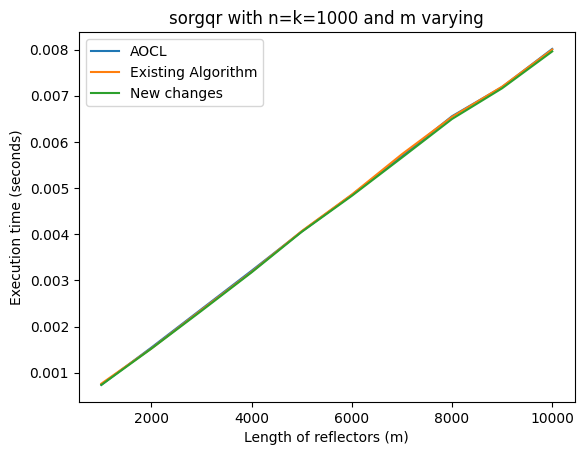

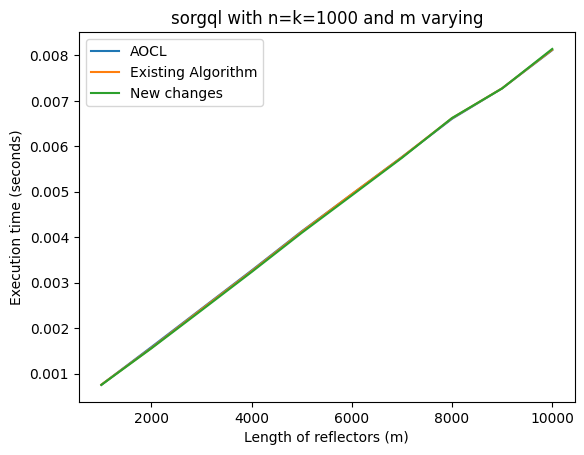

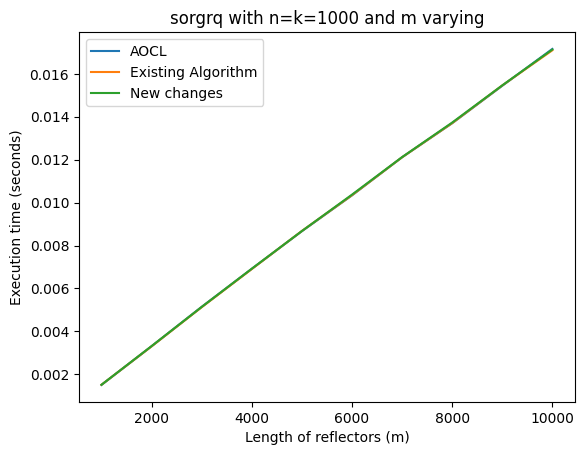

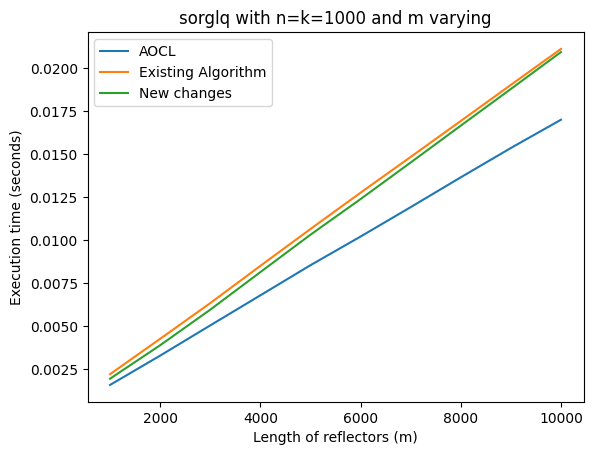

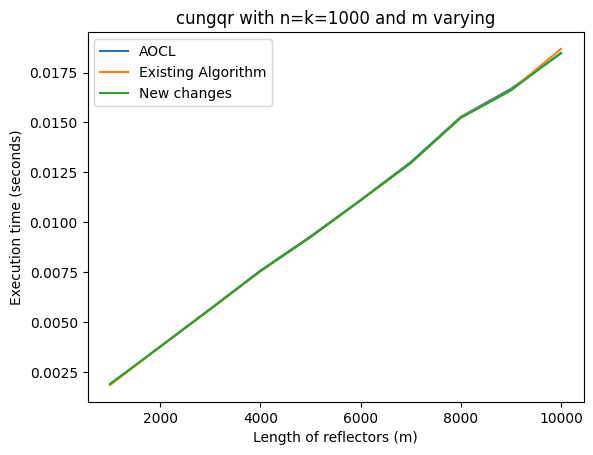

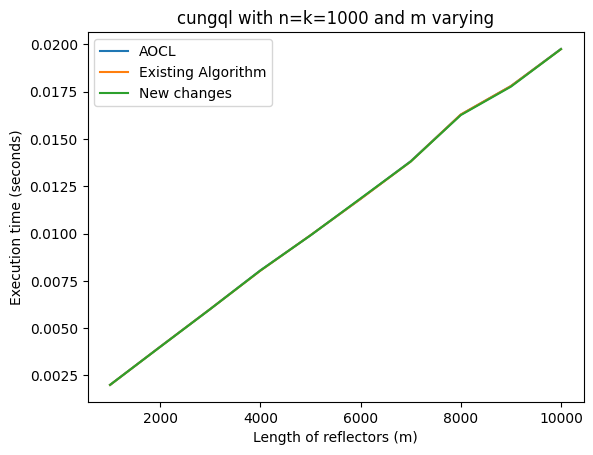

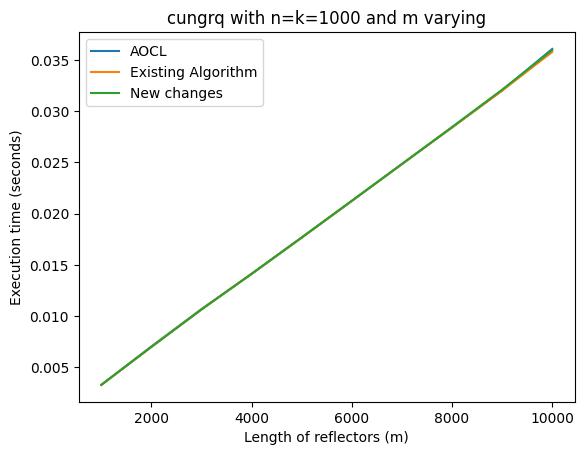

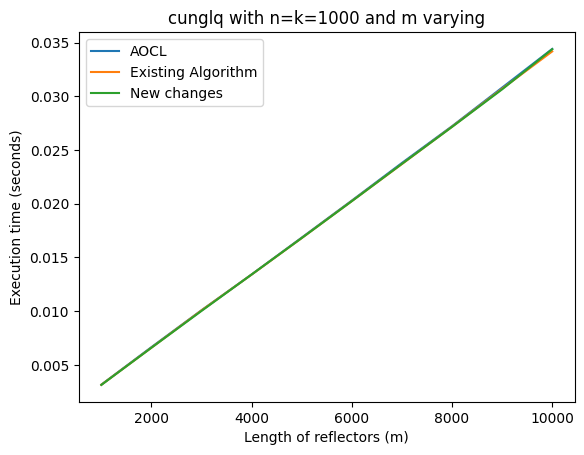

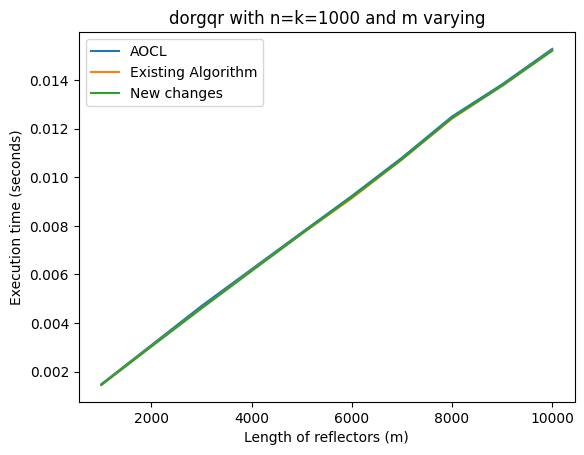

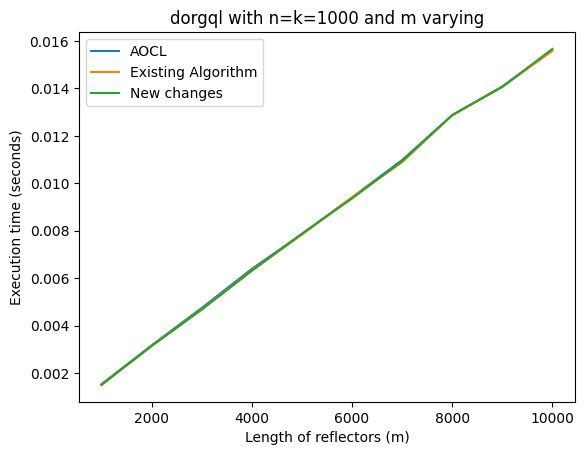

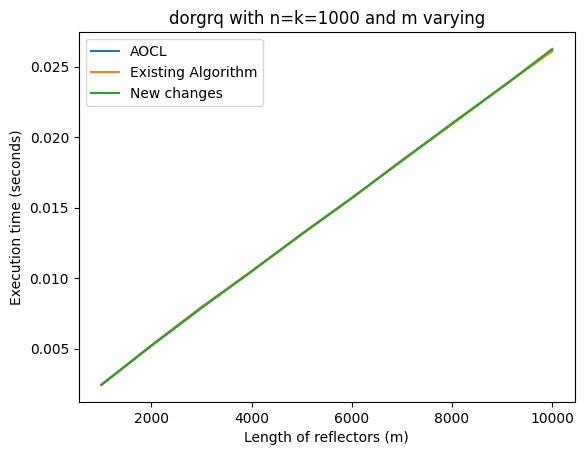

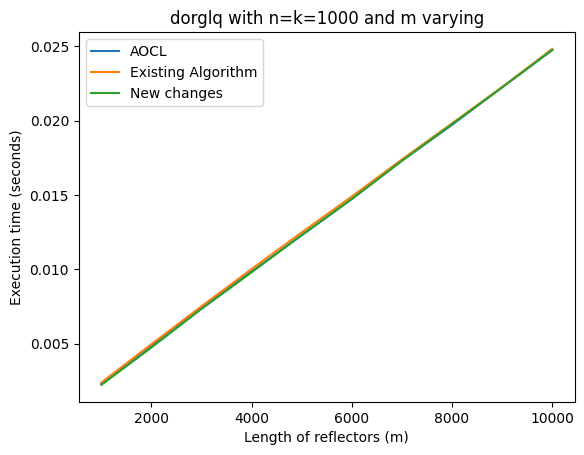

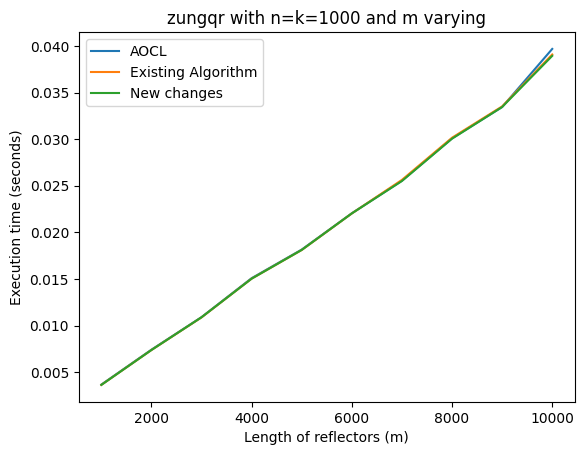

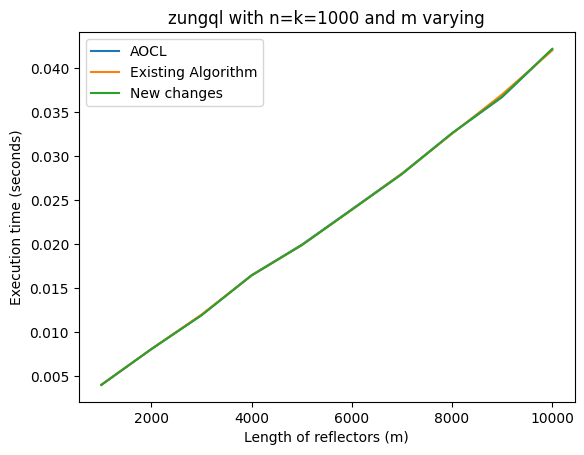

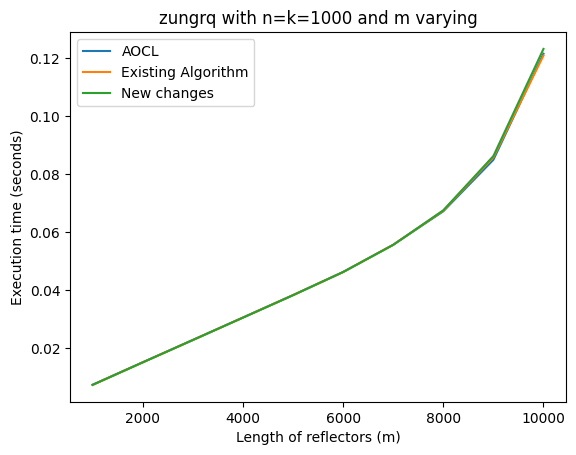

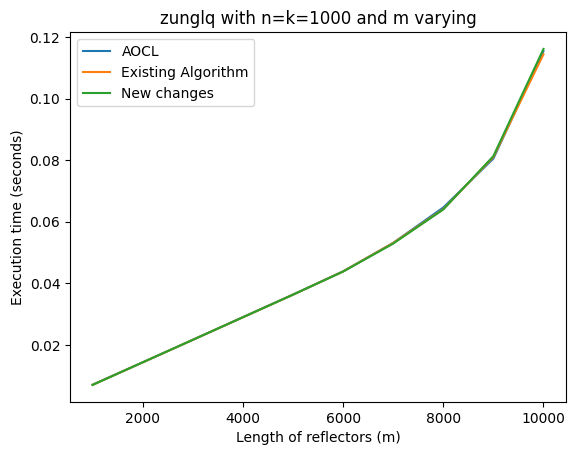

In [22]:
createFigure(mVec, np.array([single_real_qrOpt, single_real_qrRef, single_real_qrNew]), np.array(["AOCL", "Existing Algorithm", "New changes"]),
             "sorgqr with n=k=1000 and m varying", x_title, y_title)
createFigure(mVec, np.array([single_real_qlOpt, single_real_qlRef, single_real_qlNew]), np.array(["AOCL", "Existing Algorithm", "New changes"]),
             "sorgql with n=k=1000 and m varying", x_title, y_title)
createFigure(mVec, np.array([single_real_rqOpt, single_real_rqRef, single_real_rqNew]), np.array(["AOCL", "Existing Algorithm", "New changes"]),
             "sorgrq with n=k=1000 and m varying", x_title, y_title)
createFigure(mVec, np.array([single_real_lqOpt, single_real_lqRef, single_real_lqNew]), np.array(["AOCL", "Existing Algorithm", "New changes"]),
             "sorglq with n=k=1000 and m varying", x_title, y_title)
#########################################################################################################################################################
createFigure(mVec, np.array([single_complex_qrOpt, single_complex_qrRef, single_complex_qrNew]), np.array(["AOCL", "Existing Algorithm", "New changes"]),
             "cungqr with n=k=1000 and m varying", x_title, y_title)
createFigure(mVec, np.array([single_complex_qlOpt, single_complex_qlRef, single_complex_qlNew]), np.array(["AOCL", "Existing Algorithm", "New changes"]),
             "cungql with n=k=1000 and m varying", x_title, y_title)
createFigure(mVec, np.array([single_complex_rqOpt, single_complex_rqRef, single_complex_rqNew]), np.array(["AOCL", "Existing Algorithm", "New changes"]),
             "cungrq with n=k=1000 and m varying", x_title, y_title)
createFigure(mVec, np.array([single_complex_lqOpt, single_complex_lqRef, single_complex_lqNew]), np.array(["AOCL", "Existing Algorithm", "New changes"]),
             "cunglq with n=k=1000 and m varying", x_title, y_title)
#########################################################################################################################################################
createFigure(mVec, np.array([double_real_qrOpt, double_real_qrRef, double_real_qrNew]), np.array(["AOCL", "Existing Algorithm", "New changes"]),
             "dorgqr with n=k=1000 and m varying", x_title, y_title)
createFigure(mVec, np.array([double_real_qlOpt, double_real_qlRef, double_real_qlNew]), np.array(["AOCL", "Existing Algorithm", "New changes"]),
             "dorgql with n=k=1000 and m varying", x_title, y_title)
createFigure(mVec, np.array([double_real_rqOpt, double_real_rqRef, double_real_rqNew]), np.array(["AOCL", "Existing Algorithm", "New changes"]),
             "dorgrq with n=k=1000 and m varying", x_title, y_title)
createFigure(mVec, np.array([double_real_lqOpt, double_real_lqRef, double_real_lqNew]), np.array(["AOCL", "Existing Algorithm", "New changes"]),
             "dorglq with n=k=1000 and m varying", x_title, y_title)
#########################################################################################################################################################
createFigure(mVec, np.array([double_complex_qrOpt, double_complex_qrRef, double_complex_qrNew]), np.array(["AOCL", "Existing Algorithm", "New changes"]),
             "zungqr with n=k=1000 and m varying", x_title, y_title)
createFigure(mVec, np.array([double_complex_qlOpt, double_complex_qlRef, double_complex_qlNew]), np.array(["AOCL", "Existing Algorithm", "New changes"]),
             "zungql with n=k=1000 and m varying", x_title, y_title)
createFigure(mVec, np.array([double_complex_rqOpt, double_complex_rqRef, double_complex_rqNew]), np.array(["AOCL", "Existing Algorithm", "New changes"]),
             "zungrq with n=k=1000 and m varying", x_title, y_title)
createFigure(mVec, np.array([double_complex_lqOpt, double_complex_lqRef, double_complex_lqNew]), np.array(["AOCL", "Existing Algorithm", "New changes"]),
             "zunglq with n=k=1000 and m varying", x_title, y_title)

In [15]:
(mVec, nVec, kVec, single_real_qrOpt, single_real_qrRef, single_real_qrNew, single_real_qlOpt, single_real_qlRef, single_real_qlNew, \
single_real_rqOpt, single_real_rqRef, single_real_rqNew, single_real_lqOpt, single_real_lqRef, single_real_lqNew, \
double_real_qrOpt, double_real_qrRef, double_real_qrNew, double_real_qlOpt, double_real_qlRef, double_real_qlNew, \
double_real_rqOpt, double_real_rqRef, double_real_rqNew, double_real_lqOpt, double_real_lqRef, double_real_lqNew, \
single_complex_qrOpt, single_complex_qrRef, single_complex_qrNew, single_complex_qlOpt, single_complex_qlRef, single_complex_qlNew, \
single_complex_rqOpt, single_complex_rqRef, single_complex_rqNew, single_complex_lqOpt, single_complex_lqRef, single_complex_lqNew, \
double_complex_qrOpt, double_complex_qrRef, double_complex_qrNew, double_complex_qlOpt, double_complex_qlRef, double_complex_qlNew, \
double_complex_rqOpt, double_complex_rqRef, double_complex_rqNew, double_complex_lqOpt, double_complex_lqRef, double_complex_lqNew) = parseFile("tallTiming.05.September.2025.txt",perf=True)

In [16]:
x_title = "Length of reflectors (m)"
y_title = "Operations per Second (GFlop/s)"

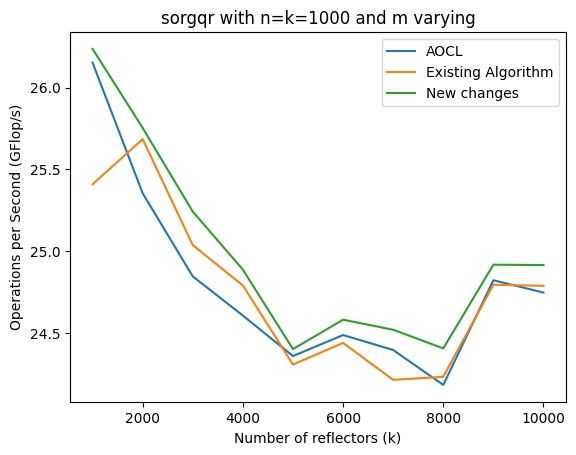

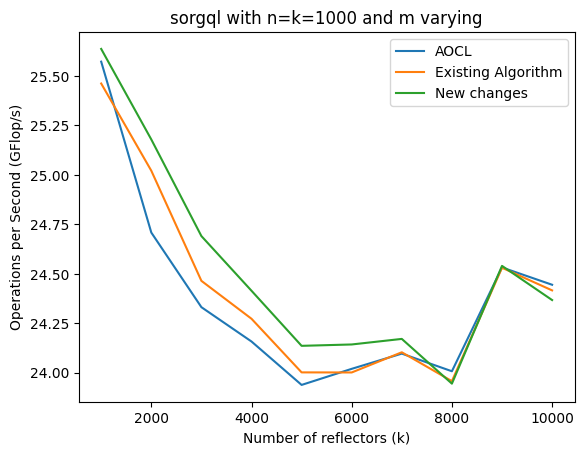

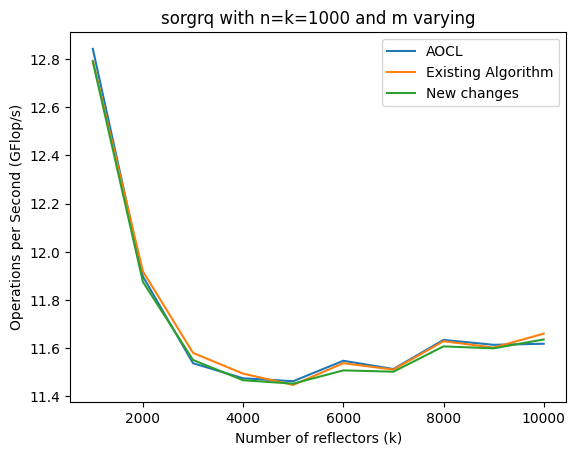

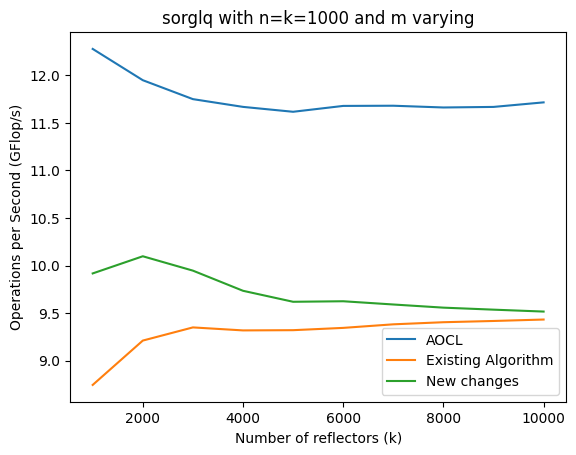

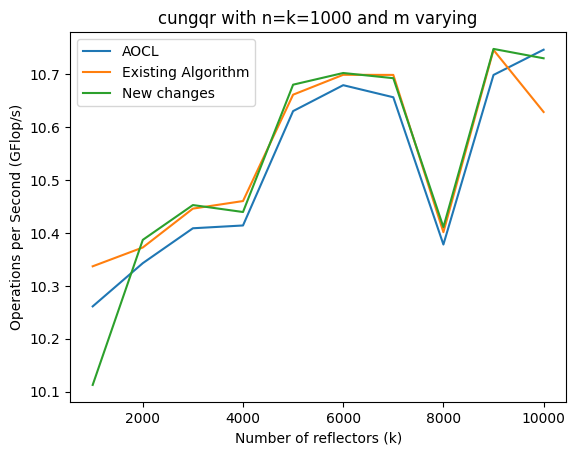

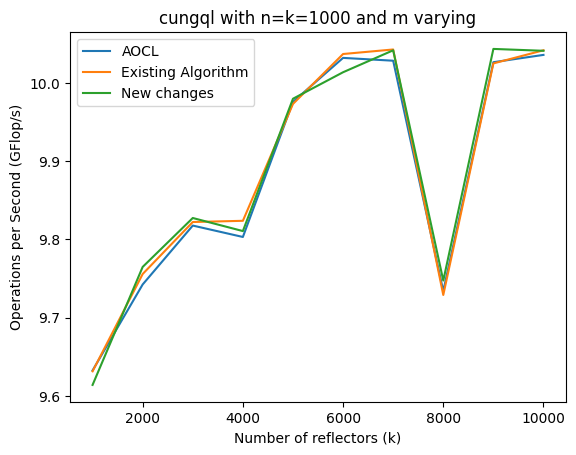

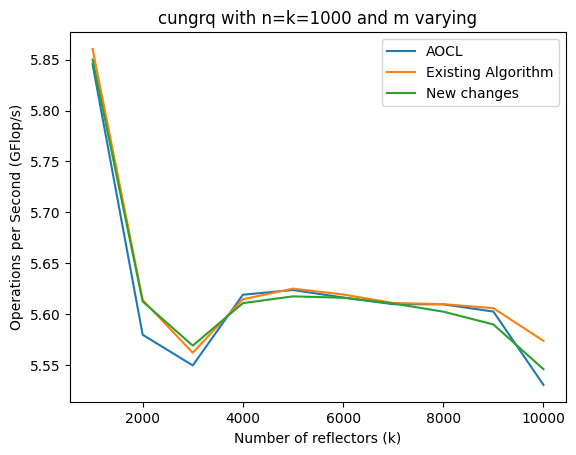

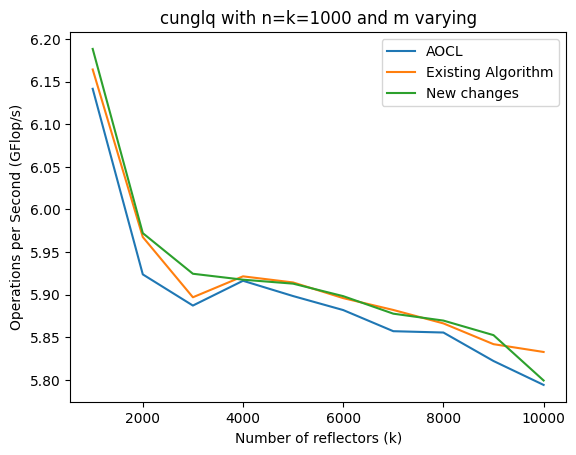

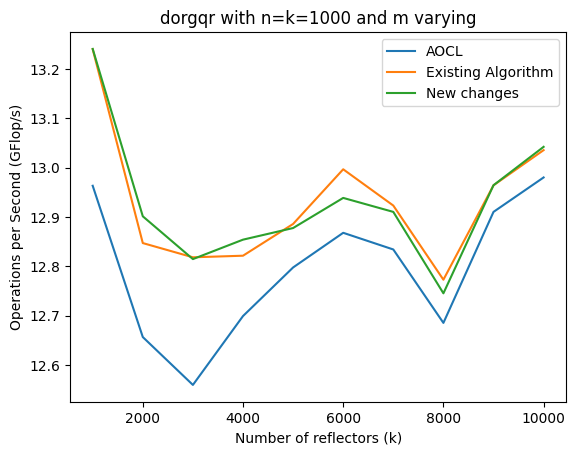

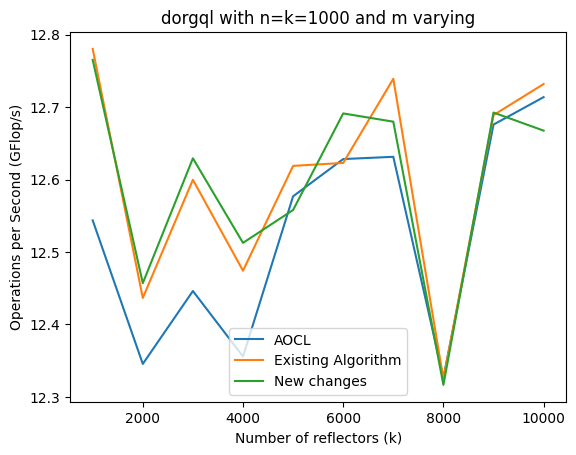

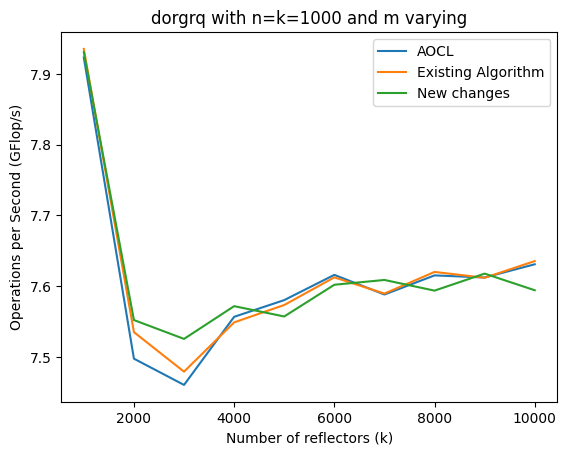

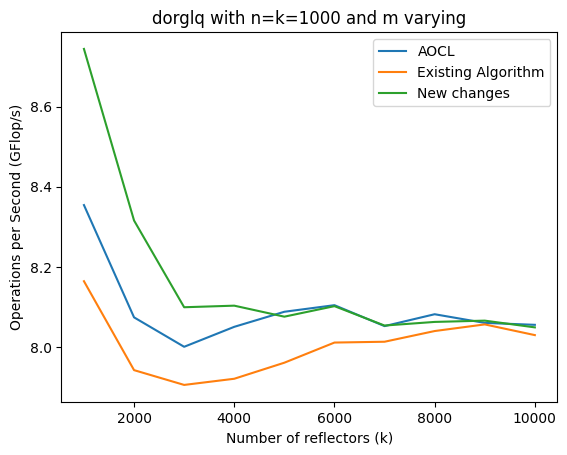

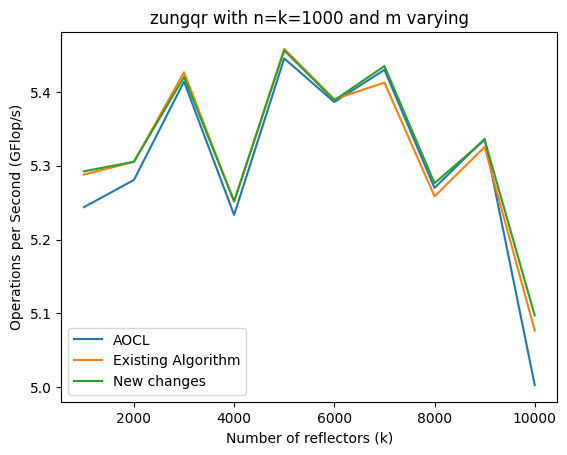

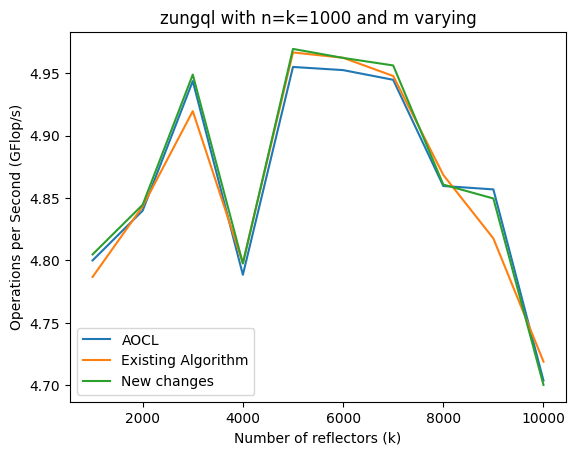

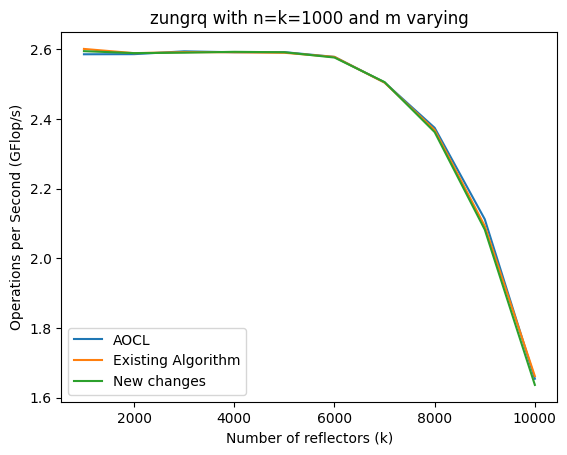

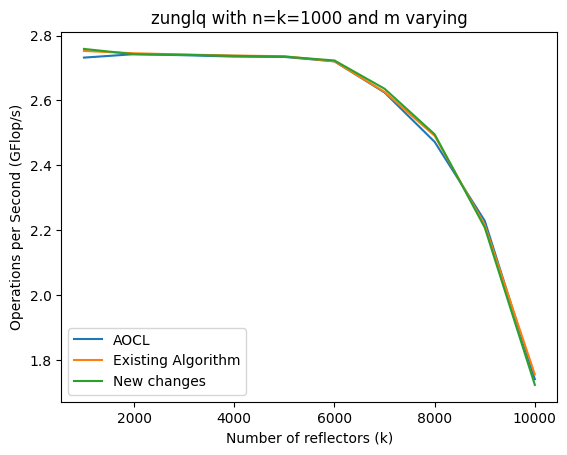

In [17]:
createFigure(mVec, np.array([single_real_qrOpt, single_real_qrRef, single_real_qrNew]), np.array(["AOCL", "Existing Algorithm", "New changes"]),
             "sorgqr with n=k=100 and m varying", x_title, y_title)
createFigure(mVec, np.array([single_real_qlOpt, single_real_qlRef, single_real_qlNew]), np.array(["AOCL", "Existing Algorithm", "New changes"]),
             "sorgql with n=k=100 and m varying", x_title, y_title)
createFigure(mVec, np.array([single_real_rqOpt, single_real_rqRef, single_real_rqNew]), np.array(["AOCL", "Existing Algorithm", "New changes"]),
             "sorgrq with n=k=100 and m varying", x_title, y_title)
createFigure(mVec, np.array([single_real_lqOpt, single_real_lqRef, single_real_lqNew]), np.array(["AOCL", "Existing Algorithm", "New changes"]),
             "sorglq with n=k=100 and m varying", x_title, y_title)
#########################################################################################################################################################
createFigure(mVec, np.array([single_complex_qrOpt, single_complex_qrRef, single_complex_qrNew]), np.array(["AOCL", "Existing Algorithm", "New changes"]),
             "cungqr with n=k=100 and m varying", x_title, y_title)
createFigure(mVec, np.array([single_complex_qlOpt, single_complex_qlRef, single_complex_qlNew]), np.array(["AOCL", "Existing Algorithm", "New changes"]),
             "cungql with n=k=100 and m varying", x_title, y_title)
createFigure(mVec, np.array([single_complex_rqOpt, single_complex_rqRef, single_complex_rqNew]), np.array(["AOCL", "Existing Algorithm", "New changes"]),
             "cungrq with n=k=100 and m varying", x_title, y_title)
createFigure(mVec, np.array([single_complex_lqOpt, single_complex_lqRef, single_complex_lqNew]), np.array(["AOCL", "Existing Algorithm", "New changes"]),
             "cunglq with n=k=100 and m varying", x_title, y_title)
#########################################################################################################################################################
createFigure(mVec, np.array([double_real_qrOpt, double_real_qrRef, double_real_qrNew]), np.array(["AOCL", "Existing Algorithm", "New changes"]),
             "dorgqr with n=k=100 and m varying", x_title, y_title)
createFigure(mVec, np.array([double_real_qlOpt, double_real_qlRef, double_real_qlNew]), np.array(["AOCL", "Existing Algorithm", "New changes"]),
             "dorgql with n=k=100 and m varying", x_title, y_title)
createFigure(mVec, np.array([double_real_rqOpt, double_real_rqRef, double_real_rqNew]), np.array(["AOCL", "Existing Algorithm", "New changes"]),
             "dorgrq with n=k=100 and m varying", x_title, y_title)
createFigure(mVec, np.array([double_real_lqOpt, double_real_lqRef, double_real_lqNew]), np.array(["AOCL", "Existing Algorithm", "New changes"]),
             "dorglq with n=k=100 and m varying", x_title, y_title)
#########################################################################################################################################################
createFigure(mVec, np.array([double_complex_qrOpt, double_complex_qrRef, double_complex_qrNew]), np.array(["AOCL", "Existing Algorithm", "New changes"]),
             "zungqr with n=k=100 and m varying", x_title, y_title)
createFigure(mVec, np.array([double_complex_qlOpt, double_complex_qlRef, double_complex_qlNew]), np.array(["AOCL", "Existing Algorithm", "New changes"]),
             "zungql with n=k=100 and m varying", x_title, y_title)
createFigure(mVec, np.array([double_complex_rqOpt, double_complex_rqRef, double_complex_rqNew]), np.array(["AOCL", "Existing Algorithm", "New changes"]),
             "zungrq with n=k=100 and m varying", x_title, y_title)
createFigure(mVec, np.array([double_complex_lqOpt, double_complex_lqRef, double_complex_lqNew]), np.array(["AOCL", "Existing Algorithm", "New changes"]),
             "zunglq with n=k=100 and m varying", x_title, y_title)